In [1]:
# Load the required libraries
import os
from typing import List
import random
import pickle
import tqdm
import gseapy as gp
from matplotlib.patches import Patch


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
from matplotlib import style
import datetime
import torch
from sklearn.metrics.pairwise import cosine_similarity
from perturbgen.configs import ROOT
from sklearn.metrics import silhouette_score

from perturbgen.src.optimal_transport import wasserstein
from adjustText import adjust_text

Set seed below and define base directory

In [2]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [3]:
np.random.seed(42)
random.seed(42)

In [4]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [5]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [6]:
res_dir = 'T_perturb/res/hspc/etv6/'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

### 1. Data Preprocessing

In [7]:
if not os.path.exists(f'{ROOT}/data/hspc/ETV6_2020_regressed_final.rds'):
    import gdown
    url= 'https://zenodo.org/records/6980009/files/ETV6_2020_regressed_final.rds'
    output = f'{ROOT}/data/hspc/TV6_2020_regressed_final.rds'
    gdown.download(url,output)

In [8]:
adata_etv6 = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/kl11/data/hspc/ETV6_2020_regressed_final.h5ad')

In [9]:
adata_etv6.layers['counts'][:10, :10].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [10]:
# move raw counts to .X
adata_etv6.layers['vst_counts'] = adata_etv6.X.copy()
adata_etv6.X = adata_etv6.layers['counts']

In [11]:
adata_etv6.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,...,sample,RNA_snn_res.1.5,RNA_snn_res.3,RNA_snn_res.4,celltypes,nCount_AUC,nFeature_AUC,nCount_BIN,nFeature_BIN,celltypes_ETV6status
D6_AAACCTGCATACGCCG,D6,20464.0,3983,350.0,4,Ctrl1,Ctrl2,0.331134,Negative,Negative,...,Ctrl1_D6,7,18,24,MEP,7.729251,178,25.0,25,Controls_MEP
D6_AAACCTGTCAACGGGA,D6,14573.0,3245,713.0,4,Ctrl1,F417.II.2,0.258236,Ctrl1_F417.II.2,Doublet,...,Ctrl1_D6,5,4,2,MEP,9.857846,209,44.0,44,Controls_MEP
D6_AAAGATGAGTAGGCCA,D6,22326.0,3946,227.0,4,Ctrl1,F417.II.2,0.514352,Negative,Negative,...,Ctrl1_D6,10,10,10,MEP,5.284772,166,11.0,11,Controls_MEP
D6_AAAGCAACAGACGTAG,D6,18957.0,3843,356.0,4,Ctrl1,F417.II.2,0.248478,Ctrl1_F417.II.2,Doublet,...,Ctrl1_D6,3,1,23,MEP,6.279548,178,16.0,16,Controls_MEP
D6_AAATGCCCATGGGACA,D6,23559.0,3809,252.0,4,Ctrl1,F417.II.2,0.245329,Negative,Negative,...,Ctrl1_D6,10,10,12,MEP,6.233890,162,23.0,23,Controls_MEP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D11_TTTGGTTGTATGGTTC,D11,13128.0,3395,357.0,4,F417.II.2,Ctrl2,0.526813,F417.II.2,Singlet,...,F417.II.2_D11,6,7,17,MkP_Mk,9.178979,197,46.0,46,Patients_MkP_Mk
D11_TTTGTCACAGCGATCC,D11,9764.0,2548,243.0,4,P214.III.8,Ctrl2,0.614371,P214.III.8,Singlet,...,P214.III.8_D11,6,24,30,MkP_Mk,7.859542,198,31.0,31,Patients_MkP_Mk
D11_TTTGTCACATCGGGTC,D11,16031.0,3768,278.0,4,P214.III.8,F417.II.2,0.799710,P214.III.8,Singlet,...,P214.III.8_D11,6,7,17,MkP_Mk,6.055754,161,20.0,20,Patients_MkP_Mk
D11_TTTGTCAGTAAGGATT,D11,25018.0,4560,417.0,4,F417.II.2,P214.III.8,0.649056,F417.II.2,Singlet,...,F417.II.2_D11,5,4,2,MkP_Mk,6.995016,172,23.0,23,Patients_MkP_Mk


In [12]:
adata_etv6.obs['HTO_classification'].value_counts()

HTO_classification
Negative                3235
Ctrl1                   1461
P214.III.8              1446
Ctrl2                   1367
F417.II.2               1281
Ctrl1_F417.II.2          346
Ctrl1_P214.III.8         301
F417.II.2_P214.III.8     299
Ctrl2_F417.II.2          230
Ctrl2_P214.III.8         208
Ctrl1_Ctrl2              138
Name: count, dtype: int64

In [13]:
adata_etv6.obs['HTO_classification.global'].value_counts()

HTO_classification.global
Singlet     5555
Negative    3235
Doublet     1522
Name: count, dtype: int64

In [14]:
adata_etv6.obs['MULTI_classification'].value_counts()

MULTI_classification
Negative                6368
P214.III.8              2318
Ctrl2                    998
F417.II.2                216
NA                       181
F417.II.2_P214.III.8      51
Ctrl2_P214.III.8          46
Ctrl1_P214.III.8          42
Ctrl2_F417.II.2           42
Ctrl1_Ctrl2               24
Ctrl1                     14
Ctrl1_F417.II.2           12
Name: count, dtype: int64

In [15]:
print(adata_etv6.obs['orig.ident'].value_counts())
adata_etv6.obs['ETV6status'].value_counts()
adata_etv6.obs['celltypes_ETV6status'].value_counts()

orig.ident
D6     6435
D11    3877
Name: count, dtype: int64


celltypes_ETV6status
Patients_MEP           3007
Controls_MEP           2034
Controls_MkP_Mk        1714
Patients_HSPC          1112
Patients_MkP_Mk         917
Patients_CMP            489
Controls_CMP            337
Patients_GMP            201
Controls_HSPC           138
Controls_CMP_Primed     126
Patients_CMP_Primed     124
Controls_GMP             80
Controls_Plt             33
Name: count, dtype: int64

In [16]:
adata_etv6.obs['ETV6status'].value_counts()

ETV6status
Patients    5850
Controls    4462
Name: count, dtype: int64

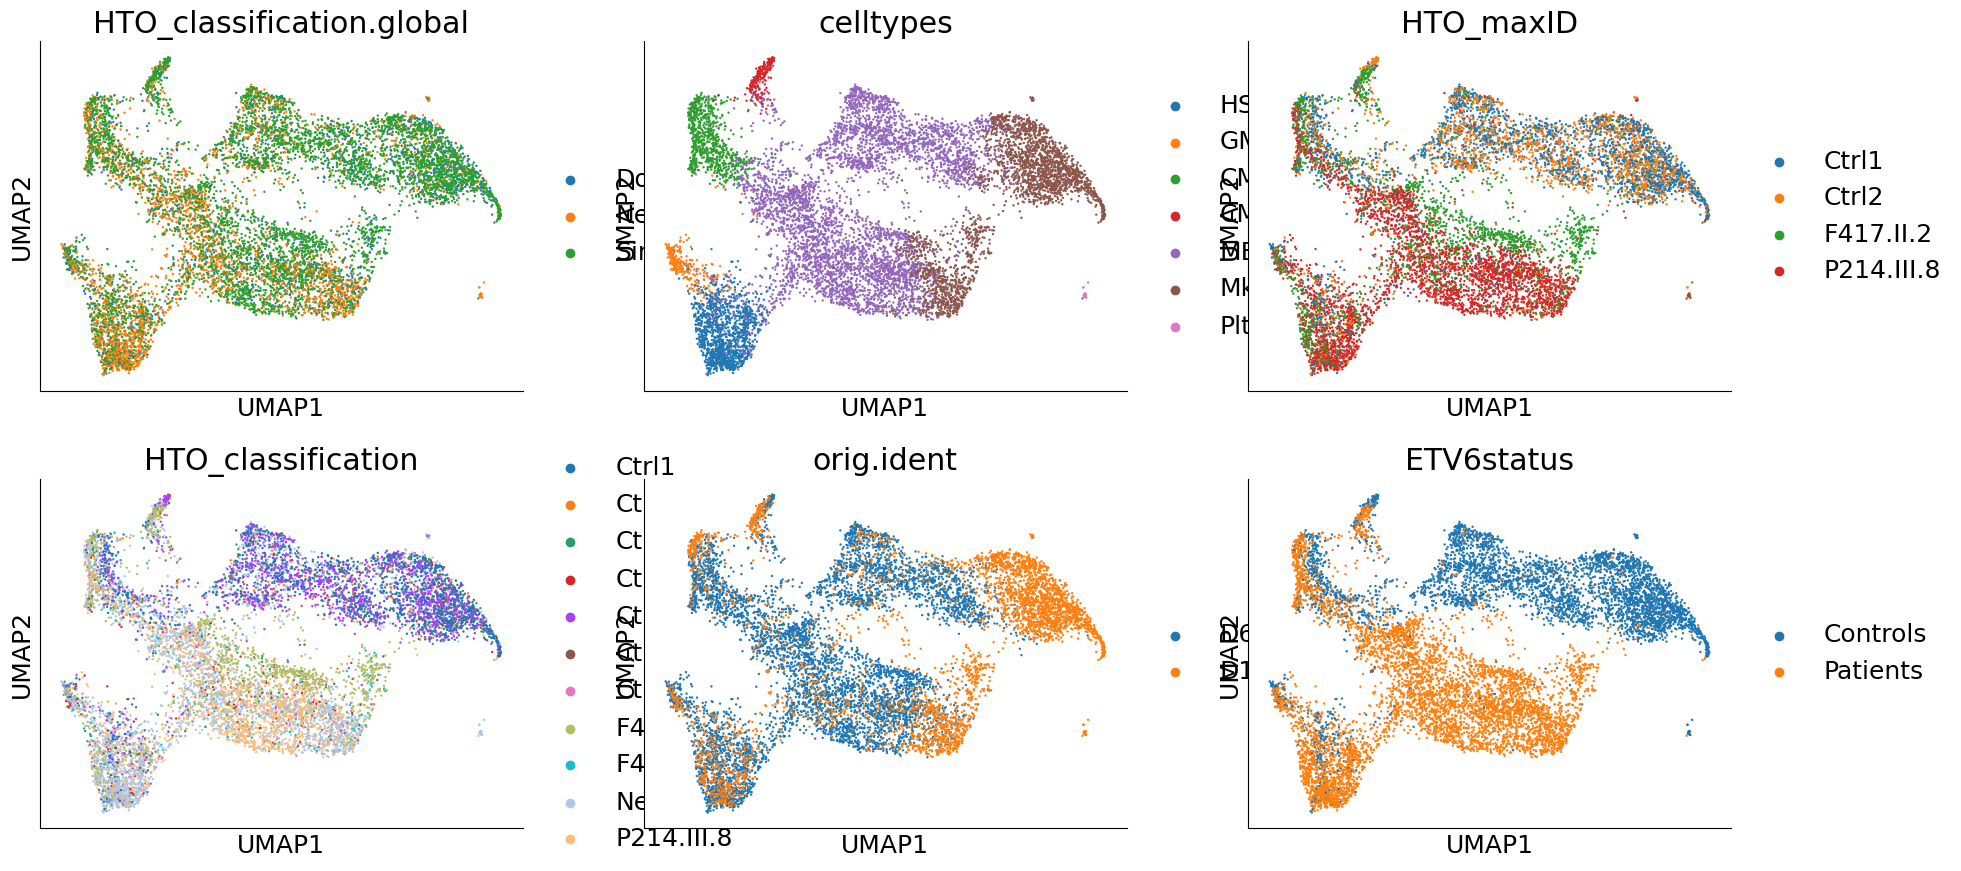

In [17]:
sc.pl.umap(
    adata_etv6,
    color=['HTO_classification.global', 'celltypes', 'HTO_maxID', 'HTO_classification', 'orig.ident', 'ETV6status'],
    ncols=3,

)

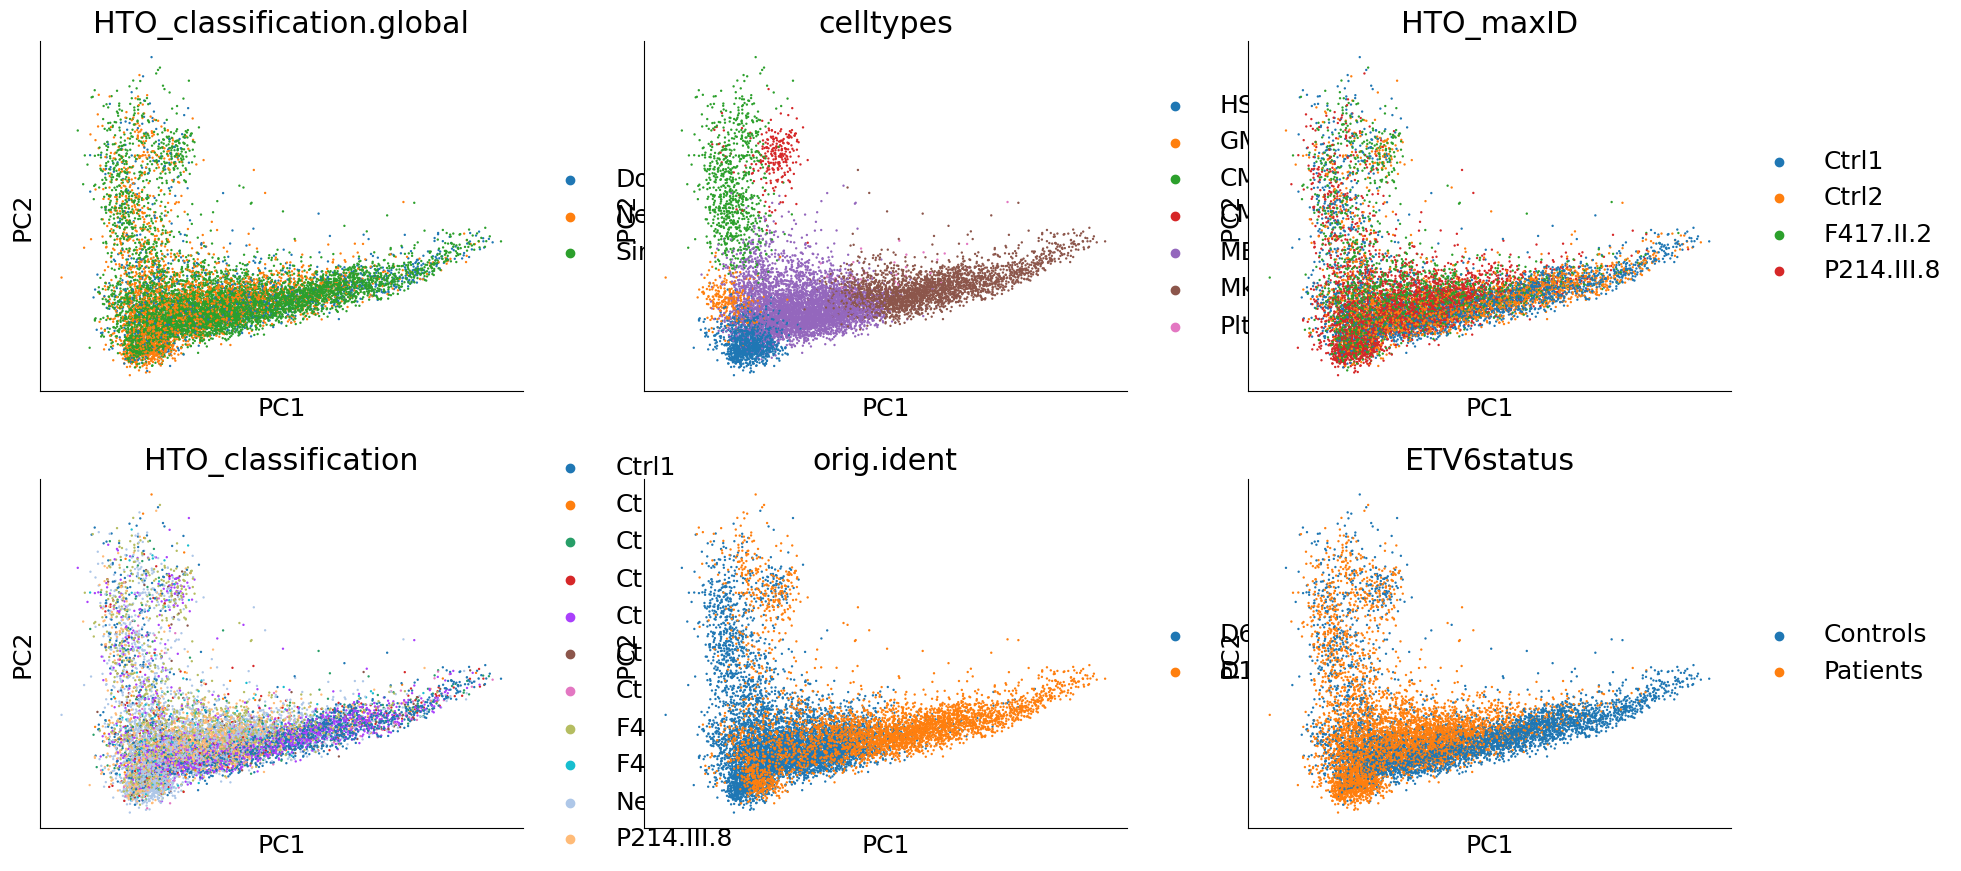

In [18]:
sc.pl.pca(
    adata_etv6,
    color=['HTO_classification.global', 'celltypes', 'HTO_maxID', 'HTO_classification', 'orig.ident', 'ETV6status'],
    ncols=3,
)

In [19]:
adata_etv6.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,...,sample,RNA_snn_res.1.5,RNA_snn_res.3,RNA_snn_res.4,celltypes,nCount_AUC,nFeature_AUC,nCount_BIN,nFeature_BIN,celltypes_ETV6status
D6_AAACCTGCATACGCCG,D6,20464.0,3983,350.0,4,Ctrl1,Ctrl2,0.331134,Negative,Negative,...,Ctrl1_D6,7,18,24,MEP,7.729251,178,25.0,25,Controls_MEP
D6_AAACCTGTCAACGGGA,D6,14573.0,3245,713.0,4,Ctrl1,F417.II.2,0.258236,Ctrl1_F417.II.2,Doublet,...,Ctrl1_D6,5,4,2,MEP,9.857846,209,44.0,44,Controls_MEP
D6_AAAGATGAGTAGGCCA,D6,22326.0,3946,227.0,4,Ctrl1,F417.II.2,0.514352,Negative,Negative,...,Ctrl1_D6,10,10,10,MEP,5.284772,166,11.0,11,Controls_MEP
D6_AAAGCAACAGACGTAG,D6,18957.0,3843,356.0,4,Ctrl1,F417.II.2,0.248478,Ctrl1_F417.II.2,Doublet,...,Ctrl1_D6,3,1,23,MEP,6.279548,178,16.0,16,Controls_MEP
D6_AAATGCCCATGGGACA,D6,23559.0,3809,252.0,4,Ctrl1,F417.II.2,0.245329,Negative,Negative,...,Ctrl1_D6,10,10,12,MEP,6.233890,162,23.0,23,Controls_MEP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D11_TTTGGTTGTATGGTTC,D11,13128.0,3395,357.0,4,F417.II.2,Ctrl2,0.526813,F417.II.2,Singlet,...,F417.II.2_D11,6,7,17,MkP_Mk,9.178979,197,46.0,46,Patients_MkP_Mk
D11_TTTGTCACAGCGATCC,D11,9764.0,2548,243.0,4,P214.III.8,Ctrl2,0.614371,P214.III.8,Singlet,...,P214.III.8_D11,6,24,30,MkP_Mk,7.859542,198,31.0,31,Patients_MkP_Mk
D11_TTTGTCACATCGGGTC,D11,16031.0,3768,278.0,4,P214.III.8,F417.II.2,0.799710,P214.III.8,Singlet,...,P214.III.8_D11,6,7,17,MkP_Mk,6.055754,161,20.0,20,Patients_MkP_Mk
D11_TTTGTCAGTAAGGATT,D11,25018.0,4560,417.0,4,F417.II.2,P214.III.8,0.649056,F417.II.2,Singlet,...,F417.II.2_D11,5,4,2,MkP_Mk,6.995016,172,23.0,23,Patients_MkP_Mk


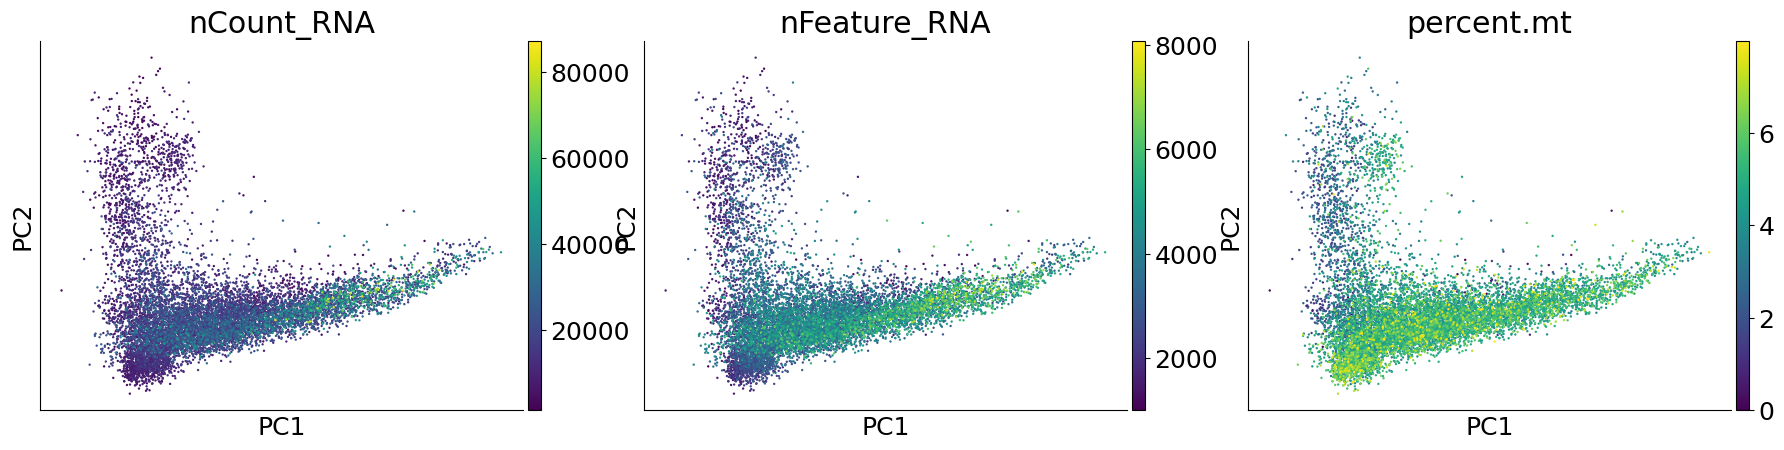

In [20]:
sc.pl.pca(
    adata_etv6,
    color=['nCount_RNA', 'nFeature_RNA', 'percent.mt'],
    ncols=3,
)

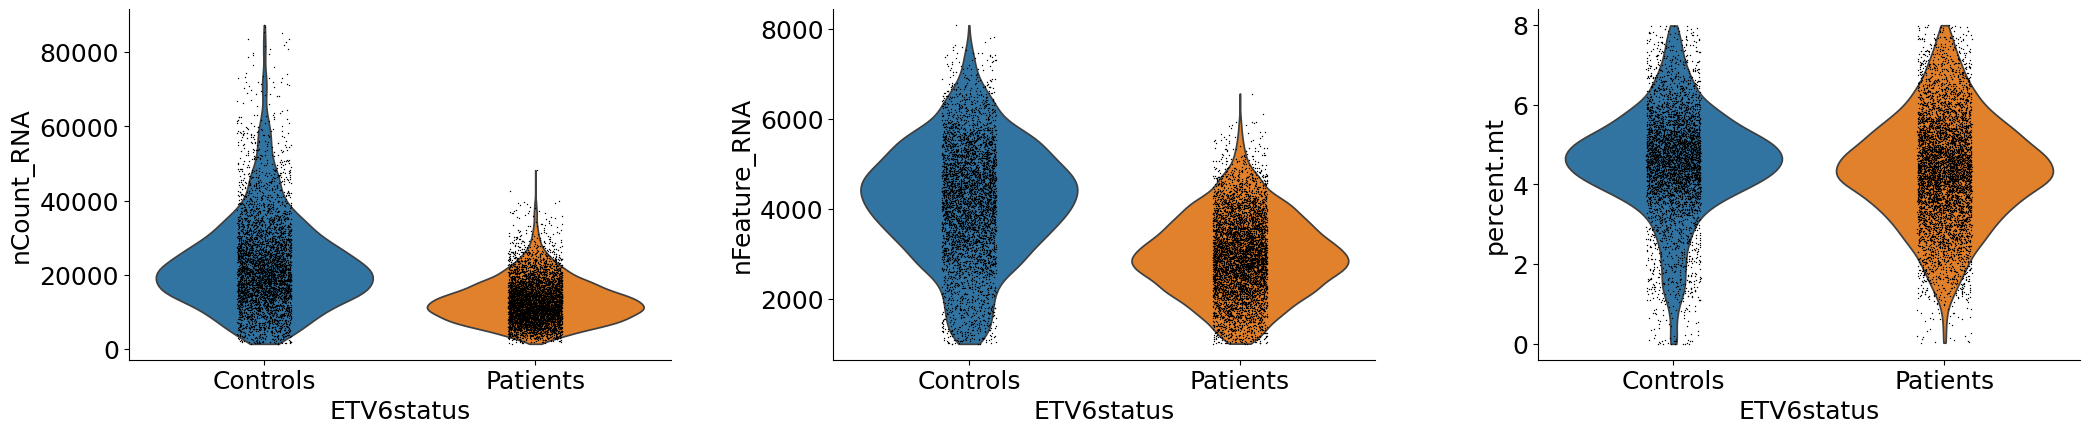

In [21]:
sc.pl.violin(
    adata_etv6,
    keys=['nCount_RNA', 'nFeature_RNA', 'percent.mt'],
    groupby='ETV6status',
)

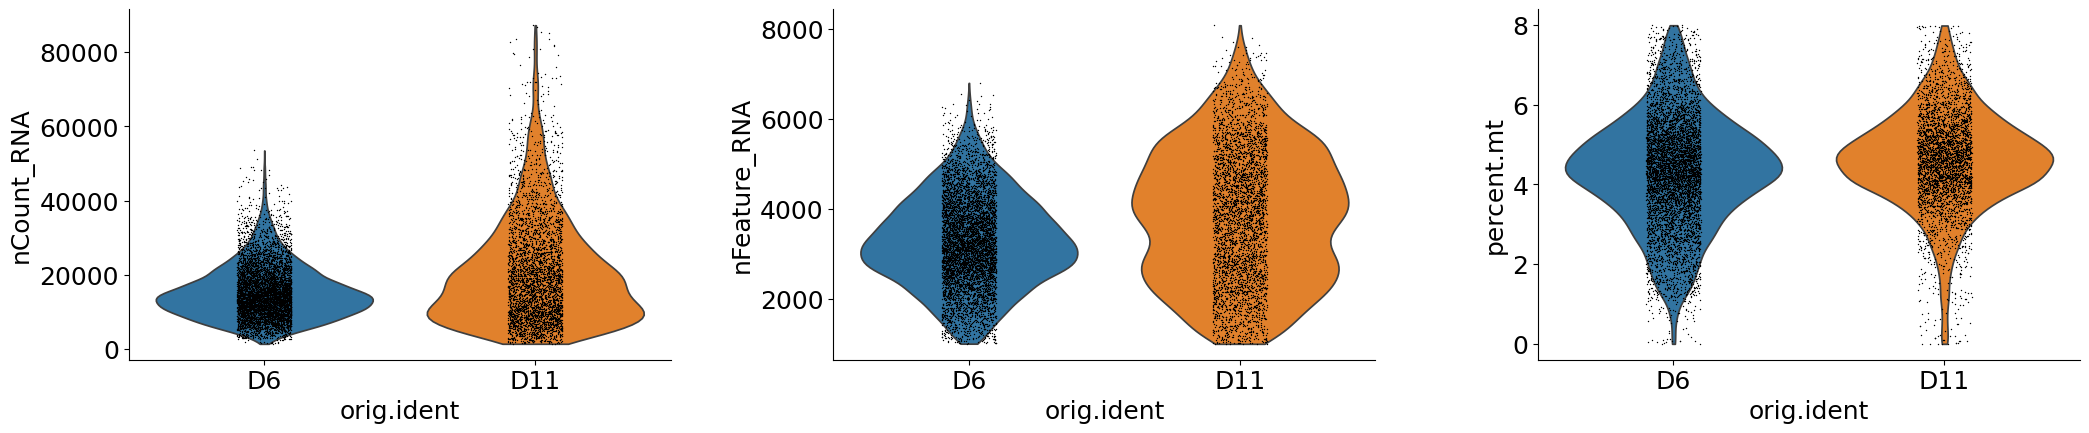

In [22]:
sc.pl.violin(
    adata_etv6,
    keys=['nCount_RNA', 'nFeature_RNA', 'percent.mt'],
    groupby='orig.ident',
)

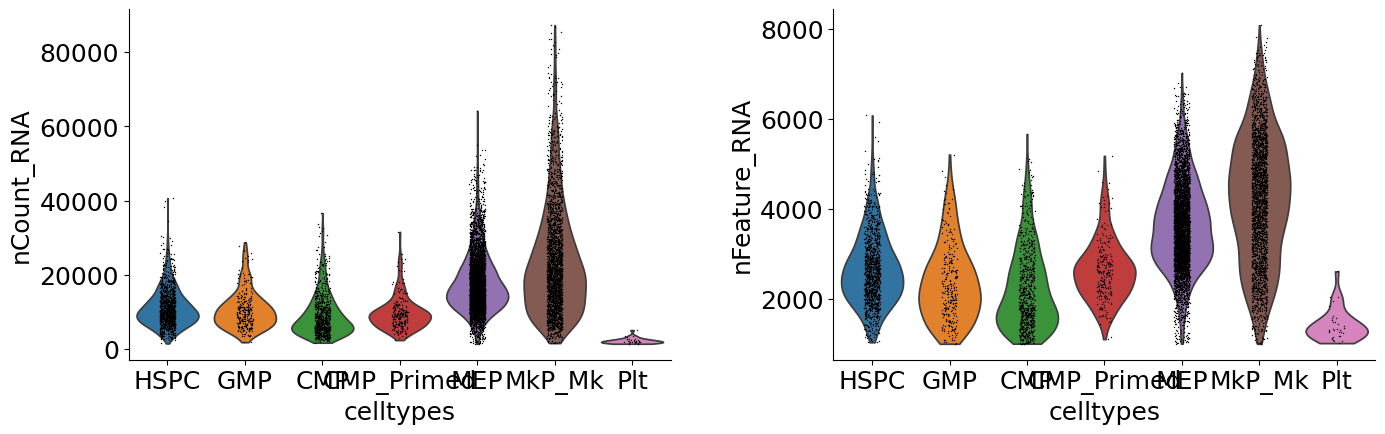

In [23]:
sc.pl.violin(
    adata_etv6,
    keys=['nCount_RNA', 'nFeature_RNA', ],
    groupby='celltypes',
)

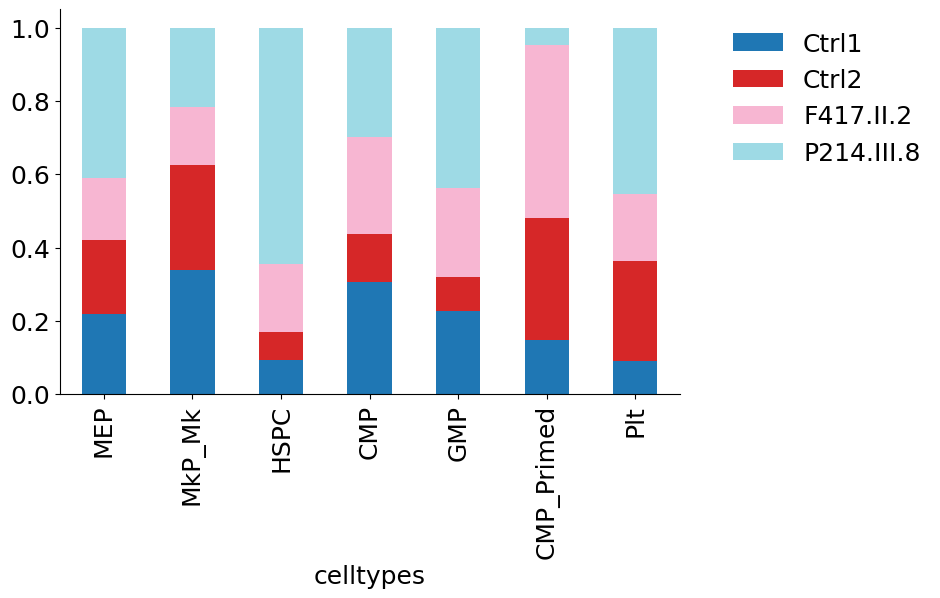

In [24]:
# plot barplot of celltype and the HFO classification
ct_hto = pd.crosstab(adata_etv6.obs['celltypes'], adata_etv6.obs['HTO_maxID'], normalize='index')
ct_hto = ct_hto.loc[adata_etv6.obs['celltypes'].value_counts().index,:]
ct_hto.plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
# plot legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

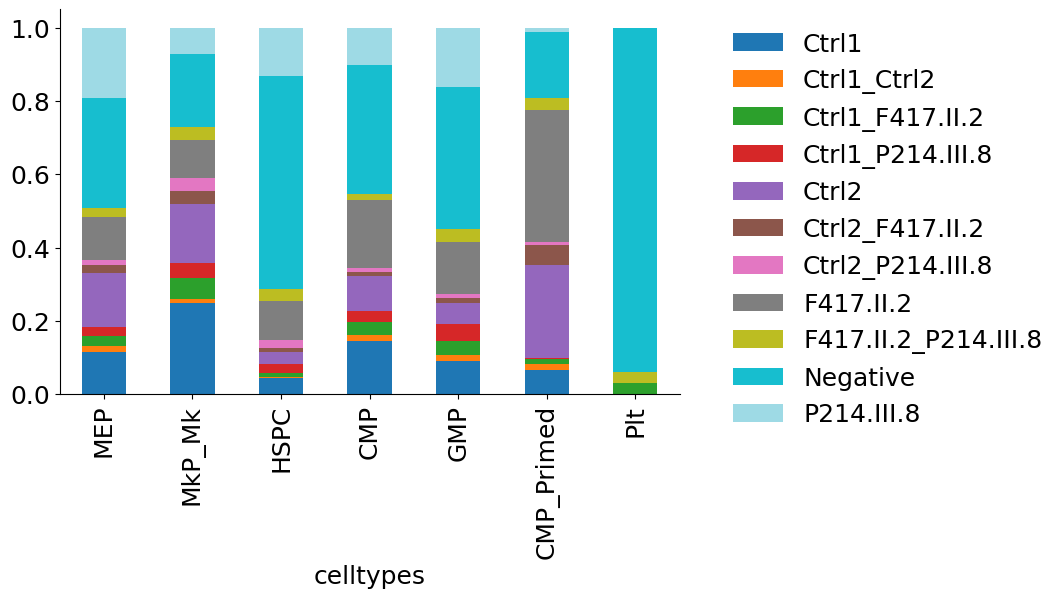

In [25]:
# plot barplot of celltype and the HFO classification
ct_hto = pd.crosstab(adata_etv6.obs['celltypes'], adata_etv6.obs['HTO_classification'], normalize='index')
ct_hto = ct_hto.loc[adata_etv6.obs['celltypes'].value_counts().index,:]
ct_hto.plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
# plot legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

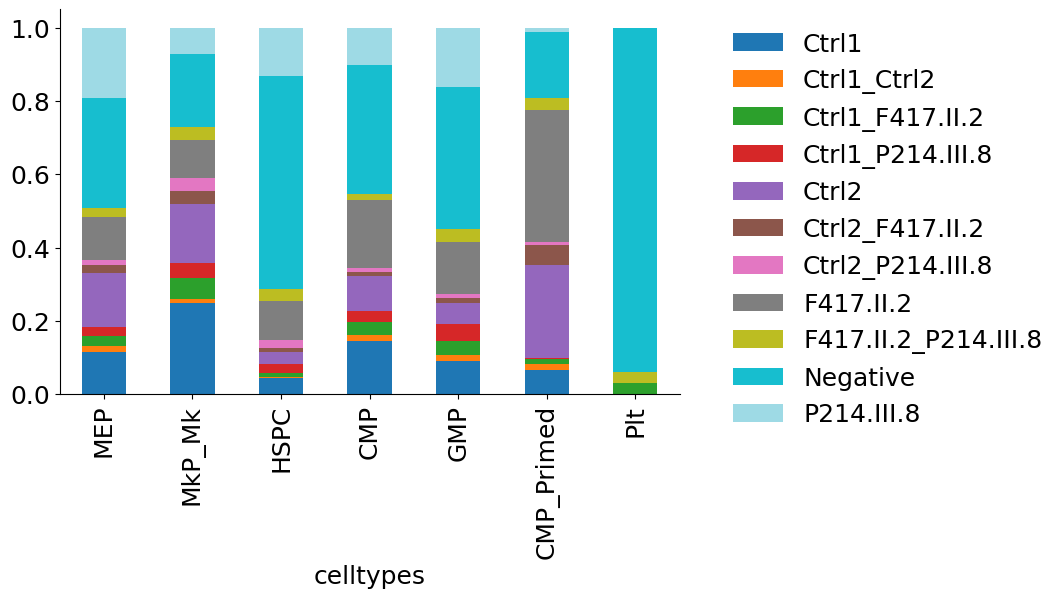

In [26]:
# plot barplot of celltype and the HFO classification
ct_hto = pd.crosstab(adata_etv6.obs['celltypes'], adata_etv6.obs['HTO_classification'], normalize='index')
ct_hto = ct_hto.loc[adata_etv6.obs['celltypes'].value_counts().index,:]
ct_hto.plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
# plot legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### Doublets check

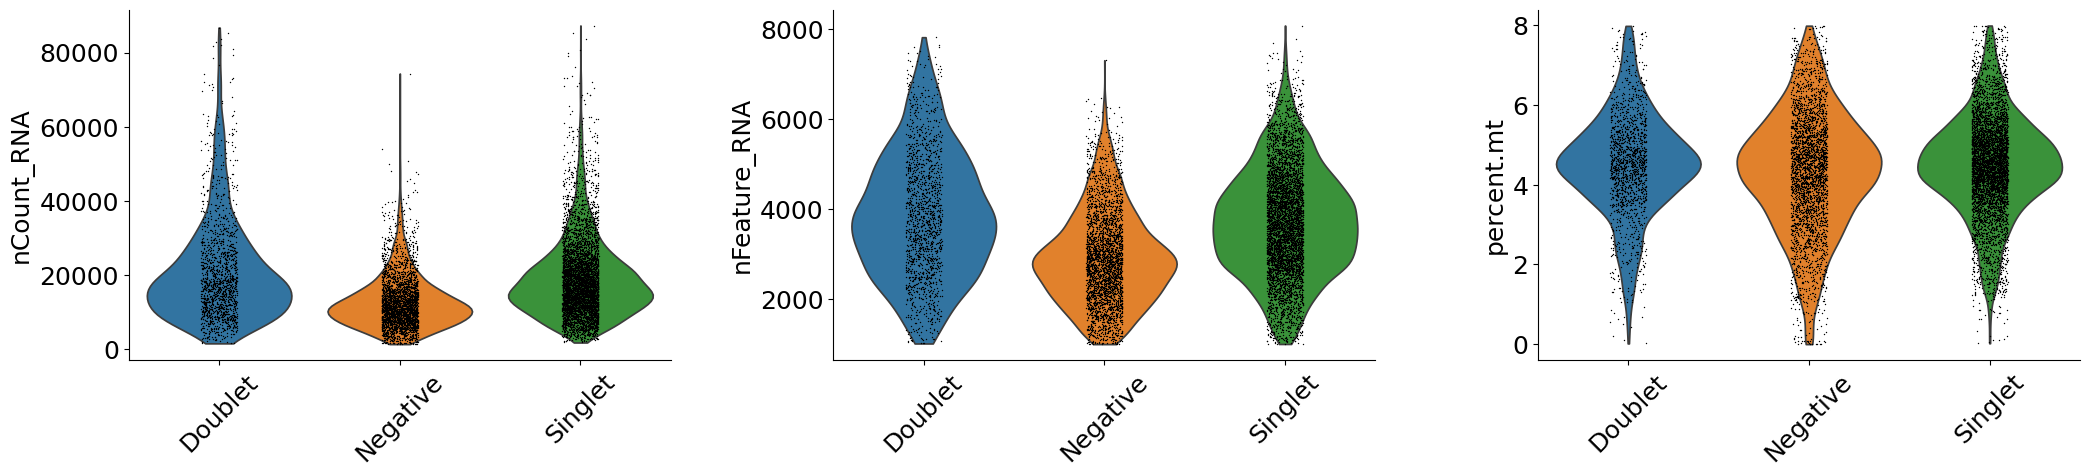

In [27]:
# plot violin plot of nCount_RNA colored by doublet status
sc.pl.violin(
    adata_etv6,
    keys=['nCount_RNA', 'nFeature_RNA', 'percent.mt'],
    groupby='HTO_classification.global',
    stripplot=True,
    rotation=45,
)

In [28]:
adata_etv6.obs['HTO_classification.global'].value_counts()

HTO_classification.global
Singlet     5555
Negative    3235
Doublet     1522
Name: count, dtype: int64

<Axes: ylabel='HT0_souporcell_classif'>

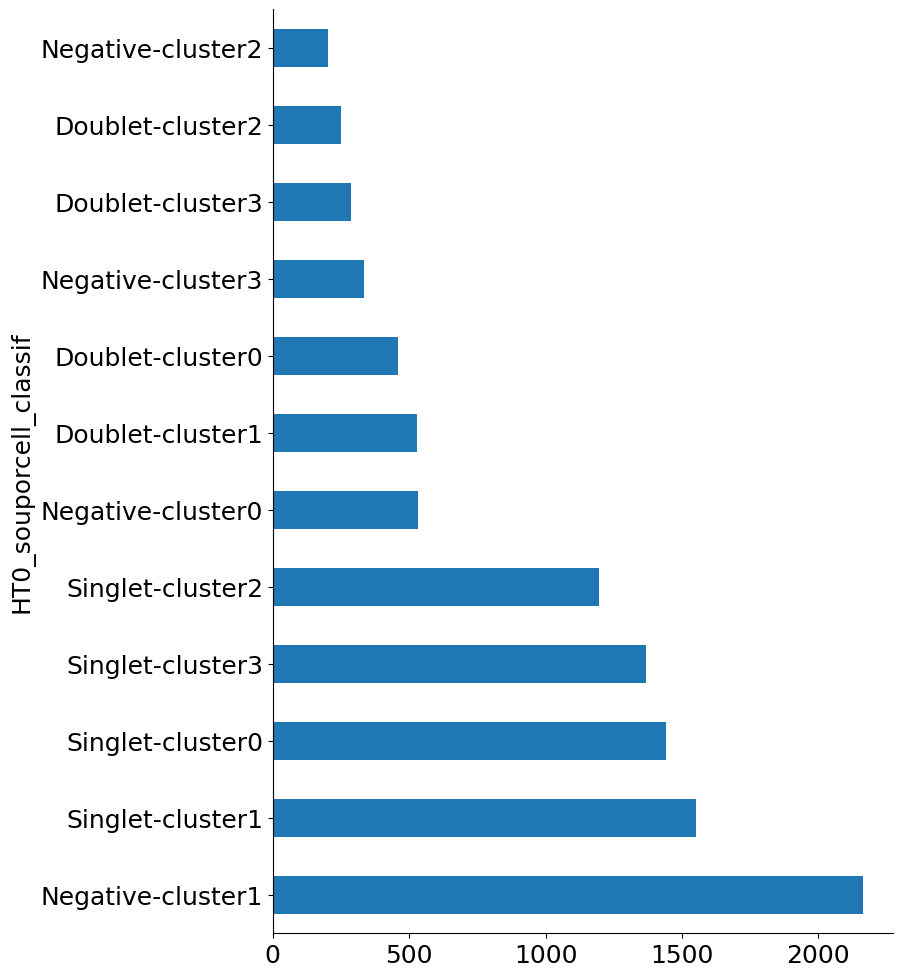

In [29]:
adata_etv6.obs['HT0_souporcell_classif'].value_counts().plot.barh(figsize=(8,12))

In [30]:
# --- helpers ---
def norm_by_row(ct):
    return ct.div(ct.sum(axis=1), axis=0)

# Confidence margin
adata_etv6.obs["delta_logprob"] = adata_etv6.obs["log_prob_singleton"] - adata_etv6.obs["log_prob_doublet"]

cluster_col = "assignment" if "assignment" in adata_etv6.obs.columns else "souporcell_classif"

In [31]:
adata_etv6.obs["HTO_classification.global"]

D6_AAACCTGCATACGCCG     Negative
D6_AAACCTGTCAACGGGA      Doublet
D6_AAAGATGAGTAGGCCA     Negative
D6_AAAGCAACAGACGTAG      Doublet
D6_AAATGCCCATGGGACA     Negative
                          ...   
D11_TTTGGTTGTATGGTTC     Singlet
D11_TTTGTCACAGCGATCC     Singlet
D11_TTTGTCACATCGGGTC     Singlet
D11_TTTGTCAGTAAGGATT     Singlet
D11_TTTGTCAGTTCGGGCT     Singlet
Name: HTO_classification.global, Length: 10312, dtype: category
Categories (3, object): ['Doublet', 'Negative', 'Singlet']

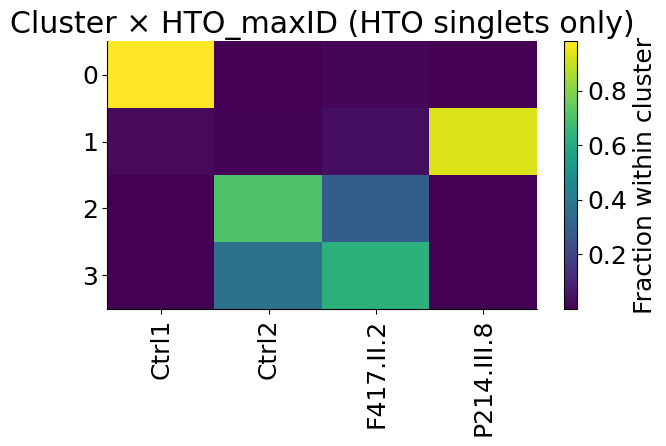

Cluster purity (max donor fraction per cluster):
assignment
0    0.980583
1    0.926452
2    0.706522
3    0.629115
dtype: float64


In [32]:
# Define HTO singlets: HTO label that is not Negative and not a combined label with "_"
hto = adata_etv6.obs["HTO_classification.global"].astype(str)
is_hto_singlet = (hto.str.lower() == 'singlet')

anchor = adata_etv6.obs.loc[is_hto_singlet].copy()

ct = pd.crosstab(anchor[cluster_col], anchor["HTO_maxID"])
ct_prop = norm_by_row(ct)

plt.figure()
plt.imshow(ct_prop.values, aspect="auto")
plt.colorbar(label="Fraction within cluster")
plt.yticks(range(ct_prop.shape[0]), ct_prop.index)
plt.xticks(range(ct_prop.shape[1]), ct_prop.columns, rotation=90)
plt.title("Cluster × HTO_maxID (HTO singlets only)")
plt.tight_layout()
plt.show()

# Optional: purity score per cluster
purity = ct_prop.max(axis=1).sort_values(ascending=False)
print("Cluster purity (max donor fraction per cluster):")
print(purity)

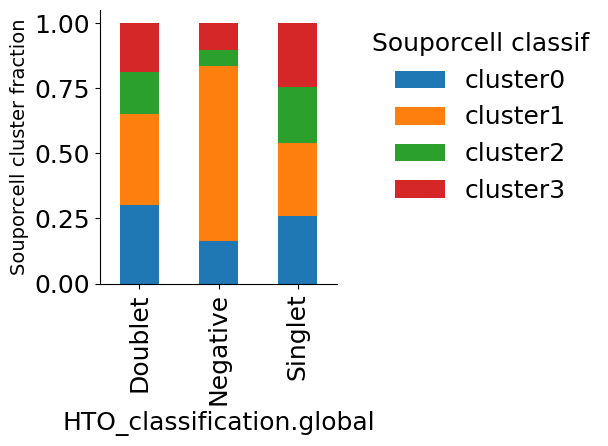

In [33]:
ct2 = pd.crosstab(adata_etv6.obs["HTO_classification.global"], adata_etv6.obs["souporcell_classif"])
ct2_prop = ct2.div(ct2.sum(axis=1), axis=0)

ct2_prop.plot(kind="bar", stacked=True)
plt.ylabel("Souporcell cluster fraction", fontsize=14)
plt.legend(title="Souporcell classif", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.title("Souporcell singlet/doublet by HTO_classification.global")
plt.tight_layout()
plt.show()

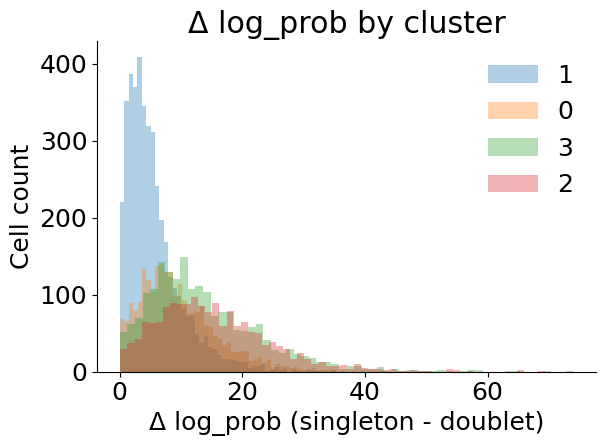

In [34]:
# Boxplot-ish via grouped hist is simple and robust
clusters = adata_etv6.obs[cluster_col].astype(str)
order = clusters.value_counts().index.tolist()

plt.figure()
for i, cl in enumerate(order):
    x = adata_etv6.obs.loc[clusters == cl, "delta_logprob"].dropna().values
    plt.hist(x, bins=60, alpha=0.35, label=cl)
plt.xlabel("Δ log_prob (singleton - doublet)")
plt.ylabel("Cell count")
plt.title("Δ log_prob by cluster")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_1147623/560772519.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(celltype_col)["is_doublet"].mean() \


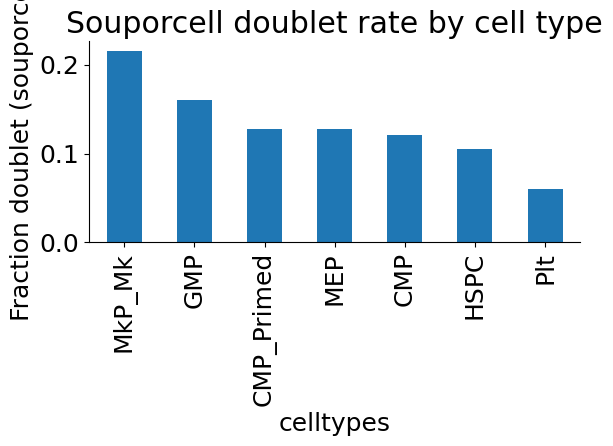

celltypes
MkP_Mk        0.215507
GMP           0.160142
CMP_Primed    0.128000
MEP           0.127951
CMP           0.121065
HSPC          0.104800
Plt           0.060606
Name: is_doublet, dtype: float64


In [35]:
celltype_col = "celltypes"

tmp = adata_etv6.obs[[celltype_col, "HTO_classification.global"]].dropna()
doublet_rate = tmp.assign(is_doublet=tmp["HTO_classification.global"].str.lower().eq("doublet")) \
                 .groupby(celltype_col)["is_doublet"].mean() \
                 .sort_values(ascending=False)

plt.figure()
doublet_rate.plot(kind="bar")
plt.ylabel("Fraction doublet (souporcell)")
plt.title("Souporcell doublet rate by cell type")
plt.tight_layout()
plt.show()

print(doublet_rate.head(15))


<Axes: xlabel='HTO_classification'>

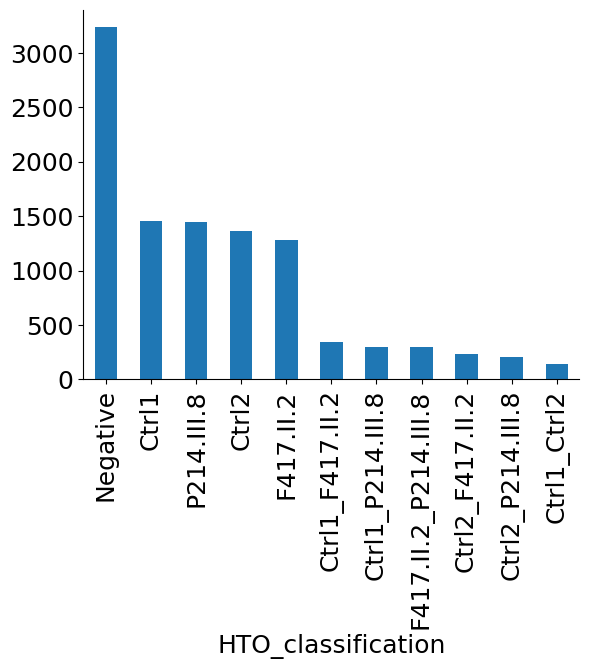

In [36]:
adata_etv6.obs['HTO_classification'].value_counts().plot.bar()

In [37]:
import numpy as np
import pandas as pd

obs = adata_etv6.obs

# Convenience
hto_global = obs["HTO_classification.global"].astype(str)
hto_maxid  = obs["HTO_maxID"].astype(str)
hs_classif = obs["HT0_souporcell_classif"].astype(str)   # e.g., "Negative-cluster1"
delta = obs["log_prob_singleton"] - obs["log_prob_doublet"]
obs["delta_logprob"] = delta

# Define which donors are patients vs controls (edit if needed)
PATIENT_DONORS = {"P214.III.8", "F417.II.2"}
CONTROL_DONORS = {"Ctrl1", "Ctrl2"}

# Pull out the souporcell cluster id from the integrated string
# (works for "Singlet-cluster1", "Negative-cluster0", etc.)
obs["soupor_cluster_from_hs"] = hs_classif.str.extract(r"(cluster\d+)")[0]

# Initialize
obs["pt_ctrl_label"] = "unassigned"

# ---- 1) Label high-confidence HTO singlets by donor ----
is_hto_singlet = hto_global.str.lower().eq("singlet")

obs.loc[is_hto_singlet & hto_maxid.isin(PATIENT_DONORS), "pt_ctrl_label"] = "patient"
obs.loc[is_hto_singlet & hto_maxid.isin(CONTROL_DONORS), "pt_ctrl_label"] = "control"

# ---- 2) Rescue HTO negatives only from clean clusters ----
# cluster0 -> control, cluster1 -> patient
is_hto_negative = hto_global.str.lower().eq("negative")

# optional confidence gate for rescued negatives
CONF_DELTA = 2  # try 0, 2, 5 depending on strictness
conf_ok = obs["delta_logprob"].gt(CONF_DELTA)

obs.loc[is_hto_negative & (obs["soupor_cluster_from_hs"] == "cluster0") & conf_ok, "pt_ctrl_label"] = "control"
obs.loc[is_hto_negative & (obs["soupor_cluster_from_hs"] == "cluster1") & conf_ok, "pt_ctrl_label"] = "patient"

# ---- 3) Exclude doublets (leave as unassigned) ----
# If you want to hard-filter them out of DE later, just subset on pt_ctrl_label != "unassigned"
# (This keeps them in the AnnData for plotting/UMAP, but prevents case/control testing on them.)

# Quick sanity counts
print(obs["pt_ctrl_label"].value_counts())

# If you want a DE-ready subset:
adata_de = adata_etv6[obs["pt_ctrl_label"].isin(["patient", "control"])].copy()
print("DE-ready cells:", adata_de.n_obs)
print(adata_de.obs["pt_ctrl_label"].value_counts())


pt_ctrl_label
patient       4441
control       3274
unassigned    2597
Name: count, dtype: int64
DE-ready cells: 7715
pt_ctrl_label
patient    4441
control    3274
Name: count, dtype: int64


In [38]:
adata_de.obs[['pt_ctrl_label', 'ETV6status']].value_counts()

pt_ctrl_label  ETV6status
patient        Patients      4441
control        Controls      3274
Name: count, dtype: int64

In [39]:
for cl in ["cluster0", "cluster1"]:
    mask_neg = (obs["HTO_classification.global"].str.lower()=="negative") & (obs["soupor_cluster_from_hs"]==cl) & (obs["pt_ctrl_label"]!="unassigned")
    mask_sing = (obs["HTO_classification.global"].str.lower()=="singlet") & (obs["soupor_cluster_from_hs"]==cl)

    print("\n", cl)
    print("delta_logprob median (neg rescued):", obs.loc[mask_neg, "delta_logprob"].median())
    print("delta_logprob median (singlets):   ", obs.loc[mask_sing, "delta_logprob"].median())



 cluster0
delta_logprob median (neg rescued): 6.923533514346584
delta_logprob median (singlets):    9.094789234368918

 cluster1
delta_logprob median (neg rescued): 5.241367663944285
delta_logprob median (singlets):    4.605331745136411


In [40]:
obs = adata_etv6.obs

# use the cluster parsed earlier
cl = obs["soupor_cluster_from_hs"].astype(str)

is_sing = obs["HTO_classification.global"].str.lower().eq("singlet")
is_neg  = obs["HTO_classification.global"].str.lower().eq("negative")

# "rescued negatives" are the ones you labeled as patient/control (not unassigned)
is_rescued_neg = is_neg & obs["pt_ctrl_label"].isin(["patient", "control"])

# focus only on cluster0/1
focus = cl.isin(["cluster0", "cluster1"])
sub = obs.loc[focus].copy()

sub["hto_group"] = np.where(
    sub.index.isin(obs.index[is_sing & focus]),
    "HTO_singlet",
    np.where(sub.index.isin(obs.index[is_rescued_neg & focus]), "HTO_negative_rescued", "other")
)

# keep just the two groups we care about
sub = sub[sub["hto_group"].isin(["HTO_singlet", "HTO_negative_rescued"])].copy()

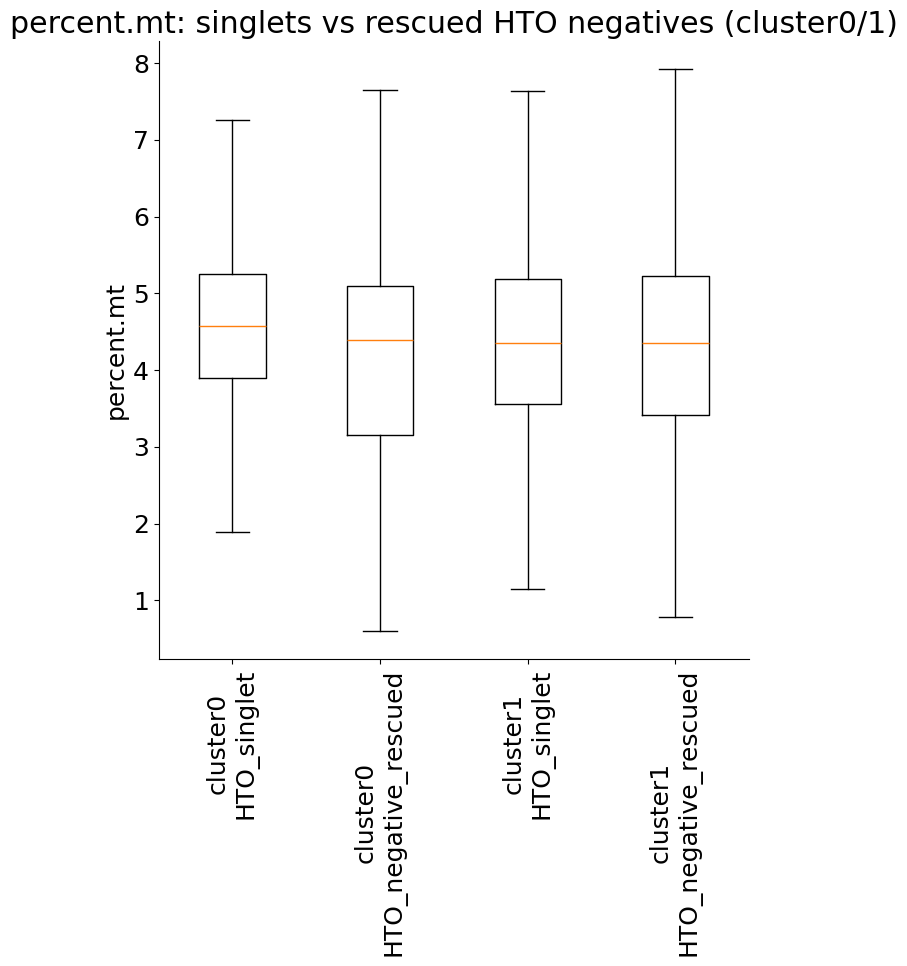

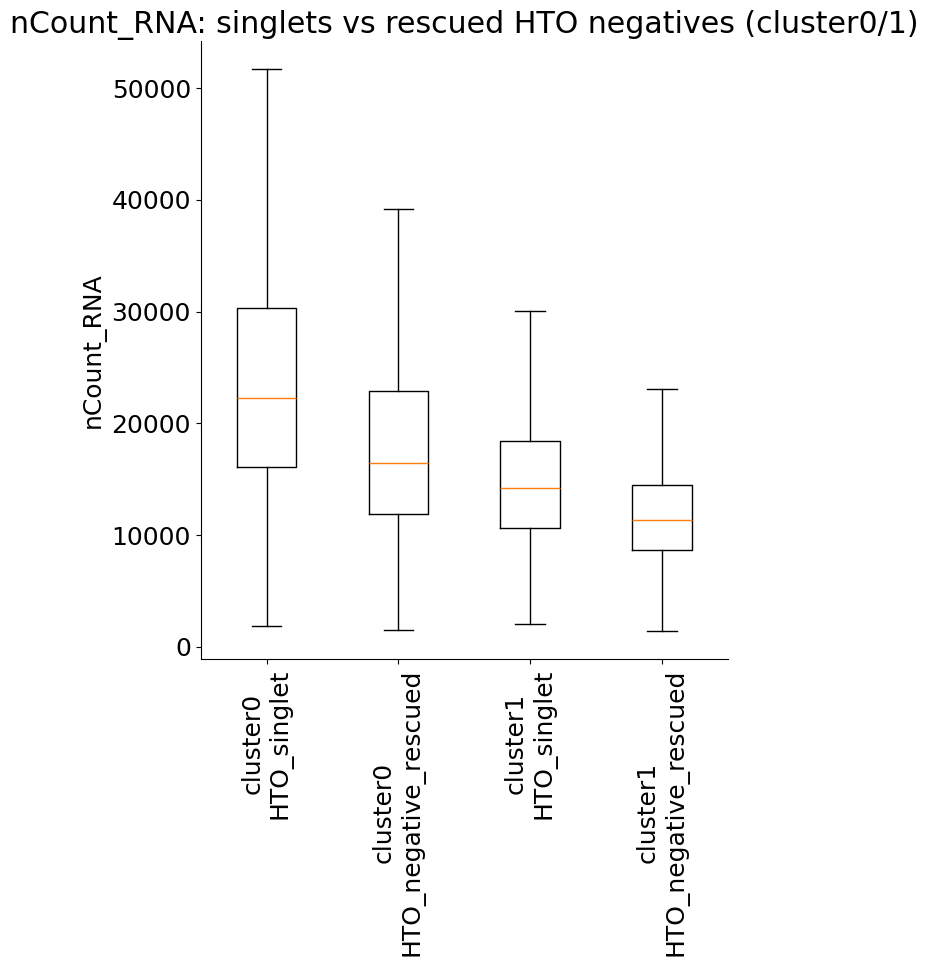

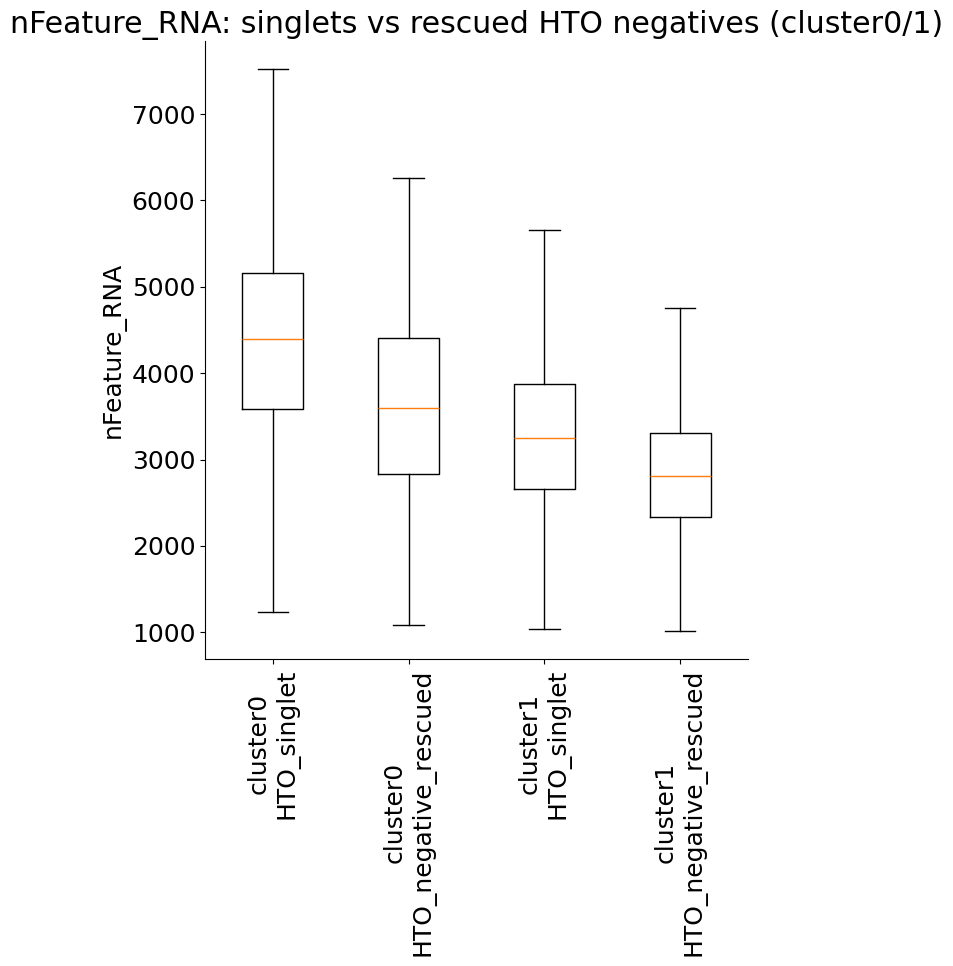

In [41]:
metrics = ["percent.mt", "nCount_RNA", "nFeature_RNA"]

for m in metrics:
    plt.figure(figsize=(7,10))
    # order: cluster0 singlet, cluster0 rescued, cluster1 singlet, cluster1 rescued
    order = [("cluster0","HTO_singlet"), ("cluster0","HTO_negative_rescued"),
             ("cluster1","HTO_singlet"), ("cluster1","HTO_negative_rescued")]
    data = [sub.loc[(sub["soupor_cluster_from_hs"]==c) & (sub["hto_group"]==g), m].dropna().values
            for c,g in order]

    plt.boxplot(data, showfliers=False)
    plt.xticks(range(1,len(order)+1), [f"{c}\n{g}" for c,g in order], rotation=90)
    plt.ylabel(m)
    plt.title(f"{m}: singlets vs rescued HTO negatives (cluster0/1)")
    plt.tight_layout()
    plt.show()

In [42]:
sc.pp.filter_cells(adata_de, min_genes=100)
sc.pp.filter_genes(adata_de, min_cells=3)

In [54]:
# save the processed data
adata_de.write_h5ad(f'{res_dir}/adata_etv6_processed.h5ad')